In [87]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [88]:
df=pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [89]:
df.shape

(920, 16)

In [90]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [91]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [92]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [93]:
df['num'].unique()

array([0, 2, 1, 3, 4], dtype=int64)

## Handling missing values

In [94]:
num_col=['trestbps','chol','thalch','oldpeak','ca']
cat_col = ['fbs', 'restecg', 'exang', 'slope', 'thal']

In [95]:
from sklearn.impute import SimpleImputer

In [96]:
num=SimpleImputer(strategy='median')
df[num_col]=num.fit_transform(df[num_col])

In [97]:
cat=SimpleImputer(strategy='most_frequent')
df[cat_col]=cat.fit_transform(df[cat_col])

In [98]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

## Removing Outlires

In [99]:
num_col=['age','trestbps','chol','thalch','oldpeak','ca']

In [100]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} -> {len(outliers)} outliers")

age -> 0 outliers
trestbps -> 28 outliers
chol -> 185 outliers
thalch -> 2 outliers
oldpeak -> 16 outliers
ca -> 128 outliers


## Using Capping to Handle outlires 

In [101]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

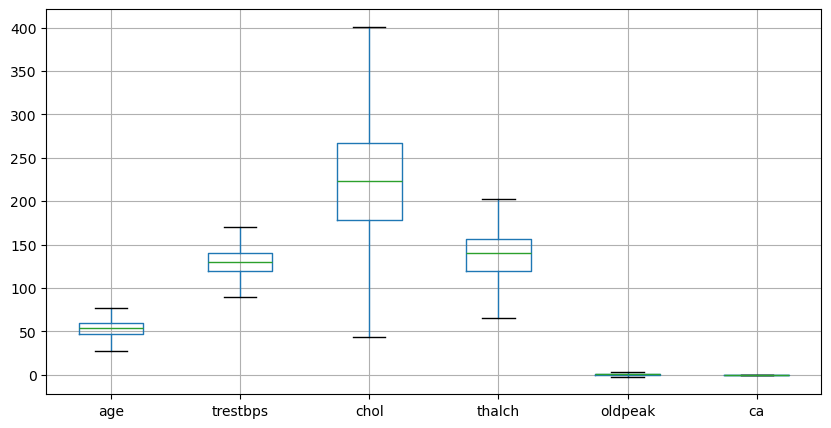

In [102]:
df[num_col].boxplot(figsize=(10,5))
plt.show()

### Now there are no outlires in the data,now its clean for Train and Testing

## Checking skewness of the Data

In [103]:
skew_values=df[num_col].skew()
print(skew_values)

age        -0.195994
trestbps    0.336341
chol       -0.587773
thalch     -0.226767
oldpeak     0.928285
ca          0.000000
dtype: float64


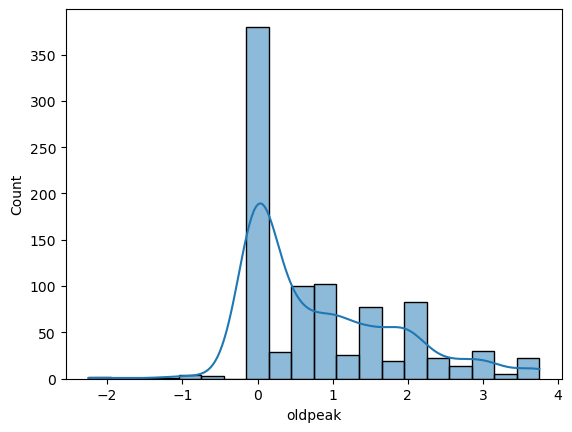

In [104]:
sns.histplot(df['oldpeak'],kde=True)
plt.show()

In [105]:
from sklearn.preprocessing import PowerTransformer

power = PowerTransformer(method='yeo-johnson')
df['oldpeak'] = power.fit_transform(df[['oldpeak']])

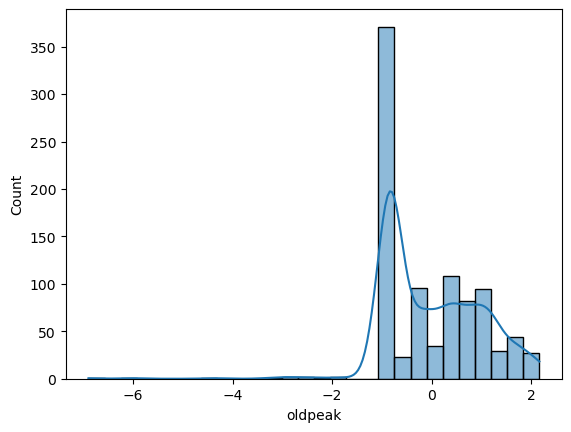

In [106]:
sns.histplot(df['oldpeak'],kde=True)
plt.show()

## One-Hot Encoding

In [107]:
X=df.drop('num',axis=1)
y = df['num']  

In [108]:
X=pd.get_dummies(X,columns=['sex','cp','fbs', 'restecg', 'exang', 'slope', 'thal'],drop_first=True)

In [109]:
X.columns

Index(['id', 'age', 'dataset', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca',
       'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

### Drop down the unnecessary columns which does not help our prediction

In [110]:
X = X.drop(['id', 'dataset'], axis=1)

## Train_test_split

In [111]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [112]:
print(X.shape,y.shape)

(920, 18) (920,)


## Standard Scalar

In [113]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Now Apply ML algorithms for prediction 

### Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [115]:
y_pred=model.predict(X_test)

## Testing the accuracy

In [116]:
from sklearn.metrics import accuracy_score
print('Accuracy:',accuracy_score(y_test,y_pred))

Accuracy: 0.5434782608695652


In [117]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[65 10  0  0  0]
 [20 31  0  3  0]
 [ 2 17  2  4  0]
 [ 7 11  6  2  0]
 [ 0  1  1  2  0]]


In [118]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.87      0.77        75
           1       0.44      0.57      0.50        54
           2       0.22      0.08      0.12        25
           3       0.18      0.08      0.11        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.31      0.32      0.30       184
weighted avg       0.47      0.54      0.49       184



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Using Decision Tree to improve the accuracy

In [119]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [120]:
y_pred=model.predict(X_test)

In [121]:
from sklearn.metrics import accuracy_score
print('accuracy_score:',accuracy_score(y_test,y_pred))

accuracy_score: 0.47282608695652173


In [122]:
## As we could see that the Decision Tree is not giving the better accuracy so we will be using the Random forest 

## Random Forest

In [123]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [124]:
y_pred=model.predict(X_test)

In [125]:
print('accuracy_score:',accuracy_score(y_test,y_pred))

accuracy_score: 0.5434782608695652


Initially, the target variable had multiple classes (0, 1, 2, 3, 4), which made the model difficult to train and reduced its accuracy. In this dataset, 0 means no disease, while 1 to 4 indicate different levels of heart disease. To make the problem simpler, the target was converted into a binary form. After this change, 0 represents no disease and 1 represents presence of disease, which helped in improving the model performance.

In [126]:
y=(df['num']>0).astype(int)

## Model Re-Traning again After Binary Classification

In [127]:
X = df.drop(['id', 'num', 'dataset'], axis=1)
y = (df['num'] > 0).astype(int)

## Encoding

In [128]:
X = pd.get_dummies(X,columns=['sex','cp','fbs','restecg','exang','slope','thal'],drop_first=True)

## Train Test Split

In [129]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Standardization

In [130]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Logistic Regression 

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [132]:
y_pred_lr = lr.predict(X_test)

In [133]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.8260869565217391


## Decision Tree

In [134]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [135]:
y_pred_dt = dt.predict(X_test)

In [136]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.75


## Random Forest

In [137]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [138]:
y_pred_rf = rf.predict(X_test)

In [139]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8478260869565217


## SVM

In [140]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [141]:
y_pred_svm = svm.predict(X_test)

In [142]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8478260869565217


## Model Evaluation

In [143]:
print(confusion_matrix(y_test, y_pred_rf))

[[64 11]
 [17 92]]


In [144]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82        75
           1       0.89      0.84      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.85      0.85       184



## Hyperparameter Tuning

In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}


In [146]:
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [147]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [148]:
best_model = grid.best_estimator_

In [149]:
y_pred = best_model.predict(X_test)

In [150]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8695652173913043


In [151]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[63 12]
 [12 97]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        75
           1       0.89      0.89      0.89       109

    accuracy                           0.87       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.87      0.87       184



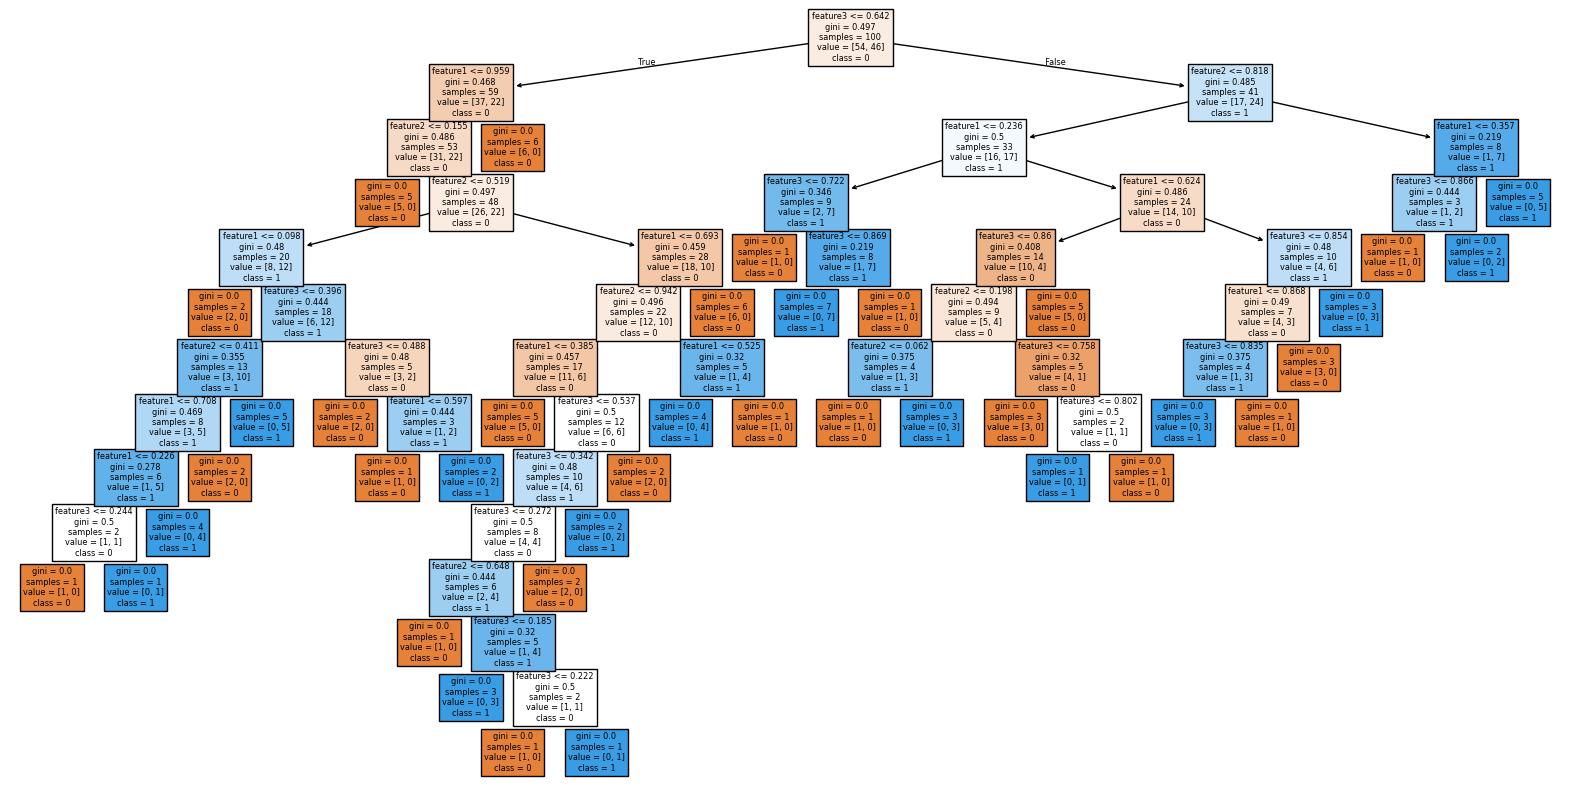

In [152]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np
# Example data (replace with your actual data)
X_train = np.random.rand(100, 3)  # Sample data with 3 features
y_train = np.random.randint(0, 2, 100)  # Binary classification labels

# Create and train the decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
plt.figure(figsize=(20,10))  # Adjust size for readability

feature_names = ['feature1', 'feature2', 'feature3']  # Replace with your actual feature names

plot_tree(dt,
          filled=True,
          feature_names=feature_names,
          class_names=[str(c) for c in dt.classes_])
plt.show()

## Simple prediction example

## Observation:

In this project, a heart disease prediction model was built using different machine learning algorithms.
At first, the model accuracy was low because the target variable had multiple classes.
Initially, the target variable had multiple classes, which made the model complex, so it was converted into a binary format (0 = no disease, 1 = disease) to improve performance. After data preprocessing and feature scaling, multiple models were trained and evaluated.

  After applying different models like Logistic Regression, Decision Tree, Random Forest, and SVM, it was observed that Random Forest gave the 
best results with an accuracy of around 87.5%. The evaluation metrics also show that the model is able to predict both disease and no disease
cases quite effectively. 

Hyperparameter tuning using GridSearchCV was also applied to improve the model performance. Among all models, Random Forest gave the best results with the highest accuracy and good balance between precision and recall. Overall, this project demonstrates how machine learning can be effectively used for early prediction of heart disease.

## Conclusion

#### Hence, Random Forest is considered the most suitable model for this dataset as it provides better accuracy compared to other models.

In [153]:
import joblib

joblib.dump(best_model, "heart_model.pkl")
joblib.dump(power, "power_transformer.pkl")

['power_transformer.pkl']

In [154]:
print(X.columns.tolist())

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


In [155]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [156]:
# ---------------------------------------------------
# Import Libraries
# ---------------------------------------------------

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [157]:
# ---------------------------------------------------
# Prepare Dataset
# ---------------------------------------------------

df = df.copy()

# Remove unwanted columns
df = df.drop(columns=["id", "dataset"])

# Convert target to binary
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Features and Target
X = df.drop("num", axis=1)

y = df["num"]

print(X.columns)
print(X.shape)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
(920, 13)


In [158]:
# ---------------------------------------------------
# Encode Categorical Columns
# ---------------------------------------------------

df["sex"] = df["sex"].map({
    "Male": 1,
    "Female": 0
})

df["cp"] = df["cp"].map({
    "typical angina": 0,
    "atypical angina": 1,
    "non-anginal": 2,
    "asymptomatic": 3
})

df["fbs"] = df["fbs"].astype(int)

df["restecg"] = df["restecg"].map({
    "normal": 0,
    "st-t abnormality": 1,
    "lv hypertrophy": 2
})

df["exang"] = df["exang"].astype(int)

df["slope"] = df["slope"].map({
    "upsloping": 0,
    "flat": 1,
    "downsloping": 2
})

df["thal"] = df["thal"].map({
    "normal": 1,
    "fixed defect": 2,
    "reversable defect": 3
})

In [159]:
X = df.drop("num", axis=1)

y = df["num"]

print(X.shape)
print(X.dtypes)

(920, 13)
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int32
restecg       int64
thalch      float64
exang         int32
oldpeak     float64
slope         int64
ca          float64
thal          int64
dtype: object


In [160]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Model
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

print(classification_report(y_test, y_pred))

Accuracy : 85.33 %
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [161]:
import joblib

model = joblib.load("heart_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [163]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

print("Features:", model.n_features_in_)

Features: 13


In [164]:
import joblib

joblib.dump(model, "heart_model_new.pkl")

print("Saved Successfully")

print(joblib.load("heart_model_new.pkl").n_features_in_)

Saved Successfully
13
